# SUPPORT VECTOR MACHINE (SVM)
### Introduction to Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for:

Classification

Regression

### Core Idea

SVM finds the best decision boundary (hyperplane) that separates classes with maximum margin.

### Used in:

Text classification

Image recognition

Bioinformatics

Fraud detection

# Hyperplanes and Margins
### Hyperplane

A hyperplane is a decision boundary that separates data points.

| Data Dimension | Hyperplane |
| -------------- | ---------- |
| 1D             | Point      |
| 2D             | Line       |
| 3D             | Plane      |
| nD             | Hyperplane |


Equation of hyperplane:              𝑤⋅𝑥+𝑏=0


    Where:
            𝑤→ weight vector
            𝑏 → bias

### Margin

Margin is the distance between the hyperplane and the nearest data points.

Maximum Margin = Better Generalization

Closest points are called Support Vectors

SVM only depends on support vectors, not all data points.

# Kernel Intuition

Sometimes data is not linearly separable.

### Idea:

Map data into a higher-dimensional space where separation becomes easy.

Example:

2D data → 3D transformation


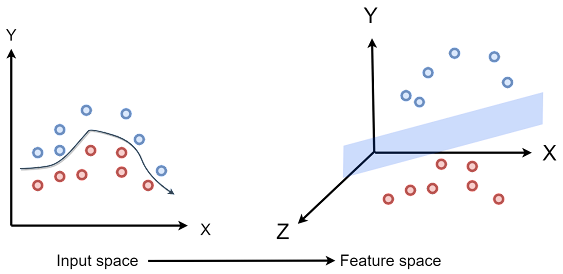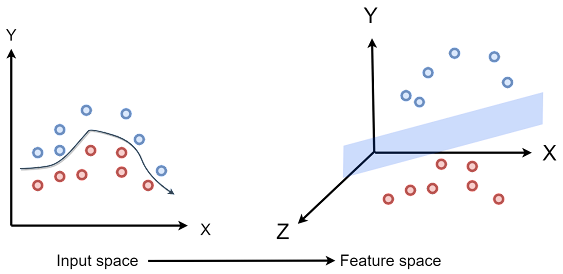



Circle → Plane separation

This transformation is done using kernels.

### Kernel Trick and Mathematics

### Kernel Trick

Instead of explicitly transforming data, SVM uses kernel functions to compute similarity.
    
                                        𝐾(𝑥𝑖,𝑥𝑗)=𝜙(𝑥𝑖)⋅𝜙(𝑥𝑗)K(xi)


### Common Kernels

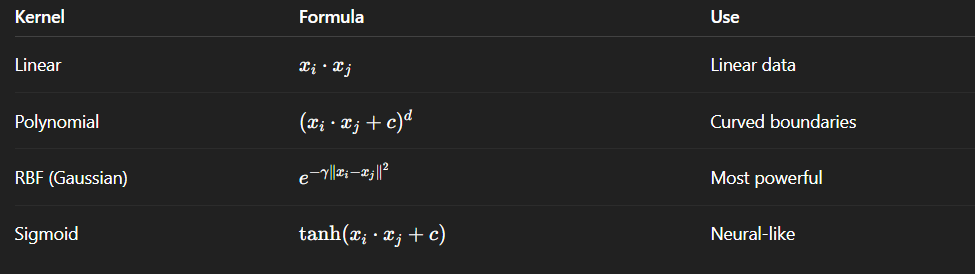


RBF kernel is the most commonly used.

### SVM for Classification

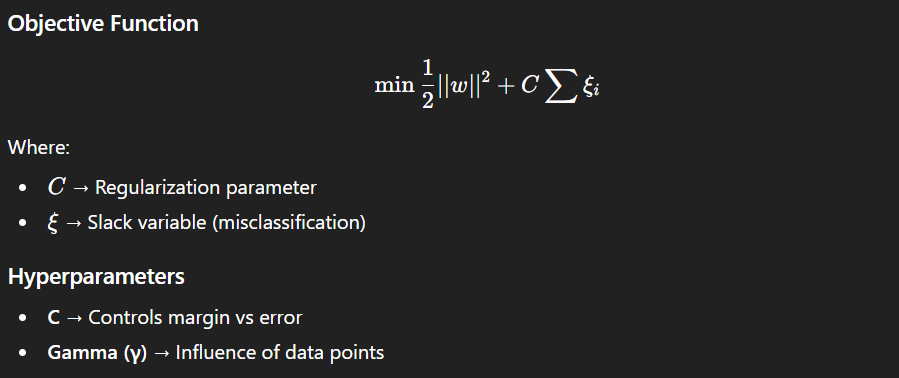

### SVM for Regression (SVR)

Instead of classification, SVR predicts continuous values.

### Key Concept:

Uses an ε-insensitive tube

Errors inside ε are ignored

### Used in:

Stock price prediction

Demand forecasting

# PRACTICAL

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, classification_report

### Load Dataset

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [3]:
df

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


### Data Cleaning

In [4]:
drop_cols = [col for col in df.columns if 'zero' in col.lower()]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [5]:
df.rename(columns={'2urvived': 'Survived'}, inplace=True)

### Data Preprocessing

In [6]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19944\1837583406.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19944\1837583406.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'].fillna(df['Age'].median(), inplace=True)


### Feature & Target Split

In [7]:
X = df.drop('Survived', axis=1)
y = df['Survived']

### Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling (VERY IMPORTANT FOR SVM)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### SVM Classification Model

In [10]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Prediction & Evaluation

In [11]:
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7900763358778626
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       189
           1       0.69      0.45      0.55        73

    accuracy                           0.79       262
   macro avg       0.75      0.69      0.70       262
weighted avg       0.78      0.79      0.77       262



### SVM Regression Example (SVR)

In [12]:
svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train, y_train)

y_pred_reg = svr.predict(X_test)

In [16]:
y_pred_reg

array([ 0.09948232,  0.10302911,  0.09953033,  0.0999962 ,  0.09981738,
        0.10539983,  0.09981738,  0.86592135,  0.10248948,  0.09890815,
        0.09196619,  0.09760741,  0.09336153,  0.89882744,  0.09946868,
        0.86931944,  0.105681  ,  0.09957112,  0.07741392,  0.10305704,
        0.082887  ,  0.09292032,  0.07871446,  0.09643292,  0.09596509,
        0.89850765,  0.09908183,  0.09898481,  0.07785123,  0.09947702,
        0.09891034,  0.84331569,  0.09985565,  0.11165877,  0.08127113,
        0.09953479,  0.1018147 ,  0.10016555,  0.09950899,  0.06941864,
        0.09819286,  0.12220947,  0.09998582,  0.07562625,  0.33557231,
        0.09941645,  0.10136408,  0.07990014,  0.09981738,  0.78529229,
        0.09949174,  0.89513327,  0.10003735,  0.99042006,  0.60234112,
        0.09952071,  0.09273854,  0.09399597,  0.20872118,  0.07284718,
        0.10789498,  0.09953479,  0.90366992,  0.08543448,  0.90865688,
        0.09922702,  0.7184966 ,  0.9065931 ,  0.09985268,  0.04